# Imports

In [12]:
# ========================================
# IMPORTS
# ========================================
import heapq
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import psutil
from collections import defaultdict, deque
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from itertools import product
import os

print("Imports completed.")

Imports completed.


# Grid Class


In [13]:
class GridEnvironment:
    """
    Represents a 2D grid-based warehouse environment.
    """

    def __init__(self, filename):
        """ Load grid from file """
        self.grid = self.load_from_file(filename)
        self.height = len(self.grid)
        self.width = len(self.grid[0]) if self.height > 0 else 0

    def is_valid_position(self, x, y):
        """ Check if position is within grid bounds """
        return 0 <= x < self.width and 0 <= y < self.height

    def is_walkable(self, x, y):
        """ Check if position is walkable (not obstacle)"""
        return self.is_valid_position(x, y) and self.grid[y][x]

    def get_neighbors(self, x, y):
        """Get adjacent cells (4-directional)"""
        directions = [(0,1), (1,0), (0,-1), (-1,0)]
        neighbors = []
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_walkable(nx, ny):
                neighbors.append((nx, ny))
        return neighbors

    def manhattan_distance(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def load_from_file(self, filename):
        """ Load grid from file (robust format handling) """
        grid = []
        max_w = 0
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            # First pass to find max width
            for line in lines:
                l = line.strip()
                if l: max_w = max(max_w, len(l))
            
            # Second pass to build grid
            for line in lines:
                l = line.strip()
                if not l: continue
                # Pad shorter lines with obstacles (T) if inhomogeneous
                l = l.ljust(max_w, 'T')
                row = []
                for char in l:
                    # '.' is walkable, anything else is obstacle
                    if char == '.':
                        row.append(True)
                    else:
                        row.append(False)
                grid.append(row)
        return grid

    def visualize(self):
        from matplotlib.colors import ListedColormap
        grid_array = np.array(self.grid, dtype=int)
        fig, ax = plt.subplots(figsize=(10, 10))
        cmap = ListedColormap(['black', 'white'])
        ax.imshow(grid_array, cmap=cmap, origin='upper')
        ax.set_title(f"Warehouse Grid ({self.width}x{self.height})")
        plt.show()

print("GridEnvironment class defined.")

GridEnvironment class defined.


# Node, Problem, Astar , Conflict Detector Classes

In [14]:
# ========================================
# NODE CLASS
# ========================================
class Node:
    """Represents a node in the search tree"""

    def __init__(self, position, parent=None, g=0, h=0):
        """Initialize a node for pathfinding
        
        Args:
            position (tuple): (x, y) coordinate or state dictionary
            parent (Node): Parent node in the path
            g (float): Cost from start to this node
            h (float): Heuristic cost from this node to goal
        """
        self.position = position
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h
        self.depth = 0 if parent is None else parent.depth + 1

    def __lt__(self, other):
        """Compare nodes for priority queue (min-heap by f value)"""
        return self.f < other.f

    def __eq__(self, other):
        """Check if two nodes represent the same position/state"""
        return self.position == other.position

    def __hash__(self):
        """Hash function for use in sets and dicts"""
        if isinstance(self.position, dict):
             return hash(str(sorted(self.position.items())))
        return hash(self.position)

    def reconstruct_path(self):
        """Reconstruct path from start to this node"""
        path = []
        current = self
        while current is not None:
            path.append(current.position)
            current = current.parent
        return list(reversed(path))

    def __repr__(self):
        return f"Node(pos={self.position}, f={self.f})"

print("Node class defined.")
# ========================================
# PROBLEM CLASS
# ========================================
class AutomatedWarehouseRobotControllerProblem:
    """
    Encapsulates the MAPF problem for N warehouse robots.
    """

    def __init__(self, initial_state):
        self.state = copy.deepcopy(initial_state)
        for robot in self.state['robots']:
            if 'path' not in robot:
                robot['path'] = [self.state['positions'][robot['id']]]

    def is_goal(self, state=None) -> bool:
        s = state if state is not None else self.state
        if s.get('collisions', 0) > 0 or s.get('deadlock', False):
            return False
        return all(robot['at_goal'] for robot in s['robots'])

    def get_valid_actions(self, state) -> list:
        grid = state['grid']
        positions = state['positions']
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (0, 0)]

        per_robot_moves = {}
        for robot in state['robots']:
            rid = robot['id']
            x, y = positions[rid]
            moves = []
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if grid.is_walkable(nx, ny):
                    moves.append((nx, ny))
            per_robot_moves[rid] = moves

        robot_ids = list(per_robot_moves.keys())
        move_lists = [per_robot_moves[rid] for rid in robot_ids]
        valid_joint_actions = []
        for combo in product(*move_lists):
            joint = dict(zip(robot_ids, combo))
            if not self._has_edge_conflict_in_action(positions, joint):
                valid_joint_actions.append(joint)
        return valid_joint_actions

    def _has_edge_conflict_in_action(self, positions, joint_action) -> bool:
        ids = list(joint_action.keys())
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                a, b = ids[i], ids[j]
                if (joint_action[a] == positions[b] and
                        joint_action[b] == positions[a]):
                    return True
        return False

    def apply_action(self, state, action) -> dict:
        new_state = copy.deepcopy(state)
        new_positions = {}
        for robot in new_state['robots']:
            rid = robot['id']
            next_pos = action[rid]
            new_positions[rid] = next_pos
            robot['path'].append(next_pos)
            robot['at_goal'] = (next_pos == robot['goal_position'])
        new_state['positions'] = new_positions
        return new_state

    def get_makespan(self, state=None) -> int:
        s = state if state is not None else self.state
        lengths = [len(r.get('path', [])) - 1 for r in s['robots']]
        return max(lengths) if lengths else 0

    def get_flowtime(self, state=None) -> int:
        s = state if state is not None else self.state
        return sum(len(r.get('path', [])) - 1 for r in s['robots'])

print("Problem class defined.")
# ========================================
# ASTAR MOTHER CLASS
# ========================================
class A_Star:
    """
    Base A* class.
    """

    def __init__(self, problem, strategy: str = "base"):
        self.problem = problem
        self.strategy = strategy

    def heuristic(self, x: int, y: int, gx: int, gy: int) -> int:
        return abs(x - gx) + abs(y - gy)

    def _check_vertex_conflict(self, pos: tuple, t: int, reservation_table: set) -> bool:
        return (pos[0], pos[1], t) in reservation_table

    def _check_edge_conflict(self, pos_from: tuple, pos_to: tuple, t: int, reservation_table: set) -> bool:
        other_was_at_to   = (pos_to[0],   pos_to[1],   t - 1) in reservation_table
        other_goes_to_src = (pos_from[0], pos_from[1], t    ) in reservation_table
        return other_was_at_to and other_goes_to_src

    def _build_reservation_table(self, paths: list) -> set:
        if not paths: return set()
        max_len = max(len(p) for p in paths)
        table = set()
        for path in paths:
            for t, pos in enumerate(path):
                table.add((pos[0], pos[1], t))
            if path:
                goal = path[-1]
                # Increased reservation horizon from 50 to 500
                for t in range(len(path), max_len + 500): 
                    table.add((goal[0], goal[1], t))
        return table

    def _astar_single_robot(self, robot, grid, reservation_table: set, start_time: int = 0, max_time: int = 1500):
        # Increased max_time from 500 to 1500
        sx, sy = robot.start_pos
        gx, gy = robot.goal_pos
        h0 = self.heuristic(sx, sy, gx, gy)
        open_heap = [(h0, 0, sx, sy, start_time)]
        came_from = {(sx, sy, start_time): None}
        g_score = {(sx, sy, start_time): 0}
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (0, 0)]

        while open_heap:
            f, g, x, y, t = heapq.heappop(open_heap)
            if (x, y) == (gx, gy):
                return self._reconstruct_path(came_from, (x, y, t))
            if t >= max_time: continue
            if g > g_score.get((x, y, t), float('inf')): continue

            nt = t + 1
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if not grid.is_walkable(nx, ny): continue
                if self._check_vertex_conflict((nx, ny), nt, reservation_table): continue
                if (dx, dy) != (0, 0) and self._check_edge_conflict((x, y), (nx, ny), nt, reservation_table):
                    continue

                new_g = g + 1
                new_state = (nx, ny, nt)
                if new_g < g_score.get(new_state, float('inf')):
                    g_score[new_state] = new_g
                    came_from[new_state] = (x, y, t)
                    h = self.heuristic(nx, ny, gx, gy)
                    heapq.heappush(open_heap, (new_g + h, new_g, nx, ny, nt))
        return None

    def _reconstruct_path(self, came_from: dict, goal_state: tuple) -> list:
        path = []
        current = goal_state
        while current is not None:
            path.append((current[0], current[1]))
            current = came_from[current]
        return list(reversed(path))

    def solve(self):
        raise NotImplementedError("Subclasses must implement solve().")

class _RobotProxy:
    def __init__(self, start_pos, goal_pos):
        self.start_pos = start_pos
        self.goal_pos = goal_pos

print("A_Star base class updated with extended time horizons.")

# ========================================
# INDEPENDENT ASTAR
# ========================================
class IndependentAStar(A_Star):
    """
    Independent A* (inherited from Mother Class).
    """

    def __init__(self, problem):
        super().__init__(problem, strategy="independent")

    def solve(self) -> dict:
        state = self.problem.state
        grid = state['grid']
        paths = {}
        for robot_data in state['robots']:
            rid = robot_data['id']
            robot_proxy = _RobotProxy(robot_data['start_position'], robot_data['goal_position'])
            path = self._astar_single_robot(robot_proxy, grid, set())
            paths[rid] = path

        valid_paths = [p for p in paths.values() if p is not None]
        makespan = max(len(p) for p in valid_paths) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths) if valid_paths else 0

        return {
            'paths': paths,
            'success': all(p is not None for p in paths.values()),
            'makespan': makespan,
            'flowtime': flowtime,
        }

print("IndependentAStar class defined.")
# ========================================
# COOPERATIVE ASTAR
# ========================================
class CooperativeAStar(A_Star):
    """
    Cooperative A* (inherited from Mother Class).
    """

    def __init__(self, problem, priority_order: list = None):
        super().__init__(problem, strategy="cooperative")
        self.priority_order = priority_order

    def solve(self) -> dict:
        state = self.problem.state
        grid = state['grid']
        robot_by_id = {r['id']: r for r in state['robots']}
        
        # Smart priority ordering: shorter paths first
        if not self.priority_order:
            order = sorted(robot_by_id.keys(), 
                           key=lambda r: grid.manhattan_distance(
                               robot_by_id[r]['start_position'], 
                               robot_by_id[r]['goal_position']
                           ))
        else:
            order = self.priority_order

        reservation_table = set()
        paths = {}
        
        # Pre-calculate max horizon for incremental updates
        all_mht = [grid.manhattan_distance(robot_by_id[r]['start_position'], robot_by_id[r]['goal_position']) for r in order]
        max_horizon = max(all_mht) * 3 + 500

        for rid in order:
            rd = robot_by_id[rid]
            robot_proxy = _RobotProxy(rd['start_position'], rd['goal_position'])
            path = self._astar_single_robot(robot_proxy, grid, reservation_table)
            paths[rid] = path
            if path:
                # Incremental reservation update (O(path_length) instead of rebuilding)
                for t, pos in enumerate(path):
                    reservation_table.add((pos[0], pos[1], t))
                goal = path[-1]
                for t in range(len(path), max_horizon):
                    reservation_table.add((goal[0], goal[1], t))

        valid_paths = [p for p in paths.values() if p is not None]
        makespan = max(len(p) for p in valid_paths) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths) if valid_paths else 0

        return {
            'paths': paths,
            'success': all(p is not None for p in paths.values()),
            'makespan': makespan,
            'flowtime': flowtime,
        }

print("CooperativeAStar class defined.")


# ========================================
# CONFLICT DETECTION SYSTEM (I got it from a star)
# ========================================
class ConflictDetector:
    """
    Combined Conflict Detection System.
    """

    def __init__(self):
        pass

    def pad_paths(self, paths: Dict) -> Dict:
        if not paths: return {}
        # Filter out None paths
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        if not valid_paths: return {}
        
        max_time = max(len(path) for path in valid_paths.values())
        padded_paths = {}
        for robot_id, path in valid_paths.items():
            goal_pos = path[-1]
            padded_paths[robot_id] = path + [goal_pos] * (max_time - len(path))
        return padded_paths

    def detect_conflicts(self, paths: Dict) -> List[Dict]:
        conflicts = []
        padded = self.pad_paths(paths)
        if not padded: return []
        
        robot_ids = list(padded.keys())
        horizon = len(next(iter(padded.values())))

        for t in range(horizon):
            # Vertex Detection
            pos_map = defaultdict(list)
            for rid in robot_ids:
                pos = padded[rid][t]
                pos_map[pos].append(rid)
            for pos, robots in pos_map.items():
                if len(robots) > 1:
                    conflicts.append({'type': 'vertex', 'time': t, 'pos': pos, 'robots': robots})
            
            # Swap Detection
            if t < horizon - 1:
                for i, r1 in enumerate(robot_ids):
                    for r2 in robot_ids[i+1:]:
                        if padded[r1][t] == padded[r2][t+1] and padded[r1][t+1] == padded[r2][t] and padded[r1][t] != padded[r1][t+1]:
                            conflicts.append({'type': 'swap', 'time': t, 'robots': [r1, r2], 'pos': (padded[r1][t], padded[r1][t+1])})
        return conflicts

    def get_report(self, paths: Dict):
        conflicts = self.detect_conflicts(paths)
        print(f"Total conflicts detected: {len(conflicts)}")
        for i, c in enumerate(conflicts[:10]):
            print(f"  {i+1}. {c['type']} at t={c['time']} involving robots {c['robots']}")
        if len(conflicts) > 10:
            print(f"  ... and {len(conflicts)-10} more.")
        return conflicts

print("ConflictDetector class defined.")

Node class defined.
Problem class defined.
A_Star base class updated with extended time horizons.
IndependentAStar class defined.
CooperativeAStar class defined.
ConflictDetector class defined.


# Conflict Node, Constraint, CBS Classes

In [15]:
import copy
import heapq
from platform import node
import time
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Set, Any


# --------------------------------------------------
# CONSTRAINT
# --------------------------------------------------
class Constraint:
    """
    CBS constraint.

    Vertex constraint:
        agent cannot be at pos1 at time t

    Edge constraint:
        agent cannot move pos1 -> pos2 at time t
    """
    def __init__(self, agent_id: int, pos1: Tuple, pos2: Optional[Tuple] = None, time: int = None):
        self.agent_id = agent_id
        self.pos1 = pos1
        self.pos2 = pos2
        self.time = time
        self.is_edge = pos2 is not None

    def __repr__(self):
        if self.is_edge:
            return f"Edge({self.agent_id}: {self.pos1}->{self.pos2}@t={self.time})"
        return f"Vertex({self.agent_id}: {self.pos1}@t={self.time})"

    def __eq__(self, other):
        return (
            isinstance(other, Constraint)
            and self.agent_id == other.agent_id
            and self.pos1 == other.pos1
            and self.pos2 == other.pos2
            and self.time == other.time
        )

    def __hash__(self):
        return hash((self.agent_id, self.pos1, self.pos2, self.time))


# --------------------------------------------------
# LOW-LEVEL ROBOT PROXY
# --------------------------------------------------
class _RobotProxy:
    def __init__(self, start_position, goal_position):
        self.start_pos = start_position
        self.goal_pos = goal_position


# --------------------------------------------------
# CT NODE
# --------------------------------------------------
class ConflictTreeNode:
    def __init__(
        self,
        constraints: Optional[Dict[int, List[Constraint]]] = None,
        paths: Optional[Dict[int, List]] = None,
        conflicts: Optional[List[Dict]] = None,
    ):
        self.constraints = constraints if constraints is not None else defaultdict(list)
        self.paths = paths if paths is not None else {}
        self.conflicts = conflicts if conflicts is not None else []
        self.makespan = self._calculate_makespan()
        self.flowtime = self._calculate_flowtime()

    def _calculate_makespan(self) -> float:
        if not self.paths:
            return float("inf")
        valid_paths = [p for p in self.paths.values() if p is not None and len(p) > 0]
        if not valid_paths:
            return float("inf")
        return max(len(p) for p in valid_paths) - 1

    def _calculate_flowtime(self) -> float:
        if not self.paths:
            return float("inf")
        valid_paths = [p for p in self.paths.values() if p is not None and len(p) > 0]
        if not valid_paths:
            return float("inf")
        return sum(len(p) - 1 for p in valid_paths)

    def __repr__(self):
        return f"CTNode(makespan={self.makespan}, flowtime={self.flowtime}, conflicts={len(self.conflicts)})"


# --------------------------------------------------
# CBS SOLVER
# --------------------------------------------------
class ConflictBasedSearch:
    """
    CBS for MAPF using:
      - variables: one path per robot
      - domains: all valid paths for each robot
      - constraints: vertex and swap constraints
      - conflict detection: your ConflictDetector
    """

    def __init__(
        self,
        problem,
        astar_class,
        conflict_detector=None,
        objective: str = "makespan",   # "makespan" or "flowtime"
        max_iterations: int = 10000,
        timeout: int = 60,
    ):
        self.problem = problem
        self.astar_class = astar_class
        self.conflict_detector = conflict_detector if conflict_detector is not None else ConflictDetector()
        self.objective = objective.lower()
        self.max_iterations = max_iterations
        self.timeout = timeout

        self.open_list = []
        self.closed_list = []
        self.high_level_iterations = 0
        self.low_level_calls = 0

    # -----------------------------
    # PUBLIC SOLVER
    # -----------------------------
    def solve(self, time_limit: Optional[float] = None, printnode: bool = False) -> Dict[str, Any]:
        if time_limit is None:
            time_limit = self.timeout

        start_time = time.time()

        initial_paths = self._get_initial_solution()
        if not initial_paths or any(p is None for p in initial_paths.values()):
            return self._failure_result(initial_paths)

        root_conflicts = self.conflict_detector.detect_conflicts(initial_paths)
        root = ConflictTreeNode(
            constraints=defaultdict(list),
            paths=initial_paths,
            conflicts=root_conflicts,
        )
        if printnode:
            print(f"Initial solution: {root}")

        self.open_list = []
        self.closed_list = []
        self.visited_nodes = set()
        self.high_level_iterations = 0

        heapq.heappush(self.open_list, (self._priority(root), id(root), root))

        while self.open_list and self.high_level_iterations < self.max_iterations:
            if time.time() - start_time > time_limit:
                break

            self.high_level_iterations += 1
            _, _, node = heapq.heappop(self.open_list)
            if printnode:
                print(node)
            self.closed_list.append(node)
            self.visited_nodes.add(id(node))

            if not node.conflicts:
                return self._success_result(node.paths)

            conflict = self._select_conflict(node.conflicts)
            
            if conflict is None:
                continue

            children = self._expand_node(node, conflict)

            for child in children:
                if child is None:
                    continue
                if id(child) not in self.visited_nodes:
                    heapq.heappush(self.open_list, (self._priority(child), id(child), child))

        return self._failure_result(None)

    # -----------------------------
    # INITIAL SOLUTION
    # -----------------------------
    def _get_initial_solution(self) -> Dict[int, List]:
        state = self._get_state()
        grid = state["grid"]
        paths = {}

        for robot_data in state["robots"]:
            rid = robot_data["id"]
            robot_proxy = _RobotProxy(robot_data["start_position"], robot_data["goal_position"])
            path = self._call_low_level_astar(robot_proxy, grid, constraints=None)
            paths[rid] = path
            self.low_level_calls += 1

        return paths

    # -----------------------------
    # NODE EXPANSION
    # -----------------------------
    def _expand_node(self, node: ConflictTreeNode, conflict: Dict) -> List[Optional[ConflictTreeNode]]:
        children = []

        for agent_id, constraint in self._constraints_from_conflict(conflict):
            child = self._create_child(node, agent_id, constraint)
            children.append(child)

        return children

    def _create_child(
        self,
        parent: ConflictTreeNode,
        agent_id: int,
        constraint: Constraint,
    ) -> Optional[ConflictTreeNode]:
        new_constraints = copy.deepcopy(parent.constraints)
        new_constraints[agent_id].append(constraint)

        new_path = self._replan_path(agent_id, new_constraints[agent_id])
        self.low_level_calls += 1

        if new_path is None:
            return None

        new_paths = copy.deepcopy(parent.paths)
        new_paths[agent_id] = new_path

        new_conflicts = self.conflict_detector.detect_conflicts(new_paths)

        return ConflictTreeNode(
            constraints=new_constraints,
            paths=new_paths,
            conflicts=new_conflicts,
        )

    # -----------------------------
    # CONFLICT -> CONSTRAINTS
    # -----------------------------
    def _constraints_from_conflict(self, conflict: Dict) -> List[Tuple[int, Constraint]]:
        """
        Returns the two CBS branches for a conflict.

        Vertex conflict:
            one child forbids each robot from occupying the vertex at that time

        Swap conflict:
            one child forbids each robot from traversing its own edge
        """
        ctype = conflict.get("type")
        robots = conflict.get("robots", [])

        if len(robots) < 2:
            return []

        r1, r2 = robots[0], robots[1]
        t = conflict["time"]

        if ctype == "vertex":
            pos = conflict["pos"]
            return [
                (r1, Constraint(r1, pos, time=t)),
                (r2, Constraint(r2, pos, time=t)),
            ]

        if ctype == "swap":
            # conflict['pos'] is (r1_from, r1_to)
            p_from, p_to = conflict["pos"]
            return [
                (r1, Constraint(r1, p_from, p_to, time=t)),
                (r2, Constraint(r2, p_to, p_from, time=t)),
            ]

        return []

    # -----------------------------
    # CONFLICT SELECTION
    # -----------------------------
    def _select_conflict(self, conflicts: List[Dict]) -> Optional[Dict]:
        if not conflicts:
            return None

        # Prefer earliest conflict; vertex before swap at same time
        return min(conflicts, key=lambda c: (c["time"], 0 if c["type"] == "vertex" else 1))

    # -----------------------------
    # LOW-LEVEL REPLAN
    # -----------------------------
    def _replan_path(self, agent_id: int, constraints: List[Constraint]) -> Optional[List]:
        state = self._get_state()
        grid = state["grid"]
        robot_data = next(r for r in state["robots"] if r["id"] == agent_id)
        robot_proxy = _RobotProxy(robot_data["start_position"], robot_data["goal_position"])

        constraint_table = self._build_constraint_table(constraints)
        return self._call_low_level_astar(robot_proxy, grid, constraints=constraint_table)

    def _build_constraint_table(self, constraints: List[Constraint]) -> Set[Tuple]:
        """
        Convert CBS constraints into the reservation format
        expected by your existing A*.

        A* expects:
            (x, y, t)

        Vertex constraint: forbid being at (x, y) at time t
            -> reserve (x, y, t)

        Edge constraint: forbid moving from pos1 to pos2 at time t
            -> reserve both:
               - pos1 at time t (can't leave from here)
               - pos2 at time t+1 (can't arrive here)
        
        This dual reservation prevents the edge traversal.
        """

        reservation_table = set()

        for c in constraints:

            # Vertex constraint: forbid agent at pos1 at time t
            if not c.is_edge:
                x, y = c.pos1
                reservation_table.add((x, y, c.time))

            # Edge constraint: forbid agent moving from pos1 to pos2 at time t
            else:
                x1, y1 = c.pos1
                x2, y2 = c.pos2
                # Reserve source at current time AND target at next time
                # This prevents the edge traversal
                reservation_table.add((x1, y1, c.time))
                reservation_table.add((x2, y2, c.time + 1))

        return reservation_table

    def _call_low_level_astar(self, robot_proxy, grid, constraints):
        """
        Call the existing A* low-level planner.

        constraints:
            reservation table in the format:
                (x, y, t)
        """

        solver = self.astar_class(self.problem)

        if constraints is None:
            constraints = set()

        return solver._astar_single_robot(
            robot_proxy,
            grid,
            constraints
        )

    # -----------------------------
    # PRIORITY / OBJECTIVE
    # -----------------------------
    def _priority(self, node: ConflictTreeNode) -> Tuple[float, float]:
        if self.objective == "flowtime":
            return (node.flowtime, node.makespan)
        return (node.makespan, node.flowtime)

    # -----------------------------
    # HELPERS
    # -----------------------------
    def _get_state(self) -> Dict:
        if hasattr(self.problem, "state"):
            return self.problem.state
        return self.problem

    def _success_result(self, paths: Dict[int, List]) -> Dict[str, Any]:
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        makespan = max(len(p) for p in valid_paths.values()) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths.values()) if valid_paths else 0

        return {
            "paths": paths,
            "success": True,
            "makespan": makespan,
            "flowtime": flowtime,
            "cbs_iterations": self.high_level_iterations,
            "low_level_calls": self.low_level_calls,
            "final_conflicts": len(self.conflict_detector.detect_conflicts(paths)),
        }

    def _failure_result(self, paths: Optional[Dict[int, List]]) -> Dict[str, Any]:
        if paths is None:
            paths = {}
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        makespan = max(len(p) for p in valid_paths.values()) - 1 if valid_paths else float("inf")
        flowtime = sum(len(p) - 1 for p in valid_paths.values()) if valid_paths else float("inf")

        return {
            "paths": paths,
            "success": False,
            "makespan": makespan,
            "flowtime": flowtime,
            "cbs_iterations": self.high_level_iterations,
            "low_level_calls": self.low_level_calls,
            "final_conflicts": len(self.conflict_detector.detect_conflicts(paths)) if paths else 0,
        }

# Hill Climbing Optimizer Class

In [16]:
class HillClimbingOptimizer:
    """
    Hill Climbing optimizer for MAPF path improvement.

    Strategies:
    1. Path Shortening: remove internal loops and redundant segments
    2. Idle Reduction: compress consecutive waiting actions
    3. Local Swap Optimization: replace a local corner with a shorter detour
    4. Adaptive Local Search: random shortcut attempts on the longest path
    """

    def __init__(self, conflict_detector=None):
        self.conflict_detector = conflict_detector or ConflictDetector()
        self.iteration_count = 0

    def optimize(
        self,
        paths: Dict,
        grid,
        max_iterations: int = 1000,
        timeout: float = 30
    ) -> Dict:
        """
        Optimize MAPF paths using a safe hill-climbing procedure.

        Args:
            paths: Dictionary of robot_id -> path
            grid: Grid environment
            max_iterations: Maximum iterations
            timeout: Timeout in seconds

        Returns:
            Optimized paths dictionary
        """
        start_time = time.time()
        original_paths = copy.deepcopy(paths)

        best_paths = copy.deepcopy(paths)
        best_score = self._solution_score(best_paths, grid, original_paths)

        improved = True
        iteration = 0

        while improved and iteration < max_iterations:
            if time.time() - start_time > timeout:
                break

            improved = False
            iteration += 1

            # Strategy 1: Path Shortening
            new_paths = self._optimize_path_shortening(best_paths, grid)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

            # Strategy 2: Idle Reduction (kept minimal to preserve collision avoidance)
            new_paths = self._optimize_idle_reduction(best_paths)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

            # Strategy 3: Local Swap Optimization
            new_paths = self._optimize_path_swaps(best_paths, grid)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

            # Strategy 4: Adaptive Local Search
            new_paths = self._optimize_adaptive_local_search(best_paths, grid)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

        self.iteration_count = iteration
        return best_paths

    def _optimize_path_shortening(self, paths: Dict, grid) -> Dict:
        """
        Remove internal loops from paths.

        The start and goal of each robot are preserved.
        """
        optimized = copy.deepcopy(paths)

        for rid, path in optimized.items():
            if not path or len(path) <= 2:
                continue

            candidate = self._remove_internal_loops(path)

            if candidate != path:
                test_paths = copy.deepcopy(optimized)
                test_paths[rid] = candidate
                # Check if conflicts exist (non-empty list) before rejecting
                conflicts = self.conflict_detector.detect_conflicts(test_paths)
                if conflicts:  # Only reject if conflicts found
                    continue
                if self._is_structurally_valid_solution(test_paths, grid, paths):
                    optimized = test_paths

        return optimized

    def _optimize_idle_reduction(self, paths: Dict) -> Dict:
        """
        Reduce idle time by compressing consecutive waiting actions.
        NOTE: Only removes back-to-back duplicates to preserve collision avoidance waiting.
        """
        optimized = copy.deepcopy(paths)

        for rid, path in optimized.items():
            if not path or len(path) <= 1:
                continue

            candidate = [path[0]]

            for pos in path[1:]:
                if pos != candidate[-1]:
                    candidate.append(pos)

            if candidate != path:
                test_paths = copy.deepcopy(optimized)
                test_paths[rid] = candidate
                # Check if conflicts exist before rejecting
                conflicts = self.conflict_detector.detect_conflicts(test_paths)
                if conflicts:  # Only reject if conflicts found
                    continue

                if self._is_structurally_valid_solution(test_paths, None, paths):
                    optimized = test_paths

        return optimized

    def _optimize_path_swaps(self, paths: Dict, grid) -> Dict:
        """
        Try local corner swaps by replacing one waypoint with a shorter detour.

        This does NOT swap entire robot paths, because that would break starts/goals.
        """
        optimized = copy.deepcopy(paths)
        robot_ids = list(optimized.keys())

        for rid in robot_ids:
            path = optimized.get(rid)
            if not path or len(path) < 3:
                continue

            for idx in range(1, len(path) - 1):
                prev_pos = path[idx - 1]
                next_pos = path[idx + 1]

                alt_path = self._find_detour(prev_pos, next_pos, grid, max_steps=4)
                if not alt_path:
                    continue

                # Accept if alt_path is strictly shorter
                # alt_path includes start and end, so length should be < 3 to improve
                if len(alt_path) >= 3:  # Must be 2 or fewer intermediate steps
                    continue

                candidate = path[:idx] + alt_path[1:-1] + path[idx + 1:]

                if candidate != path:
                    test_paths = copy.deepcopy(optimized)
                    test_paths[rid] = candidate
                    # Check if conflicts exist before rejecting
                    conflicts = self.conflict_detector.detect_conflicts(test_paths)
                    if conflicts:  # Only reject if conflicts found
                        continue
                    if self._is_structurally_valid_solution(test_paths, grid, paths):
                        optimized = test_paths
                        break

        return optimized

    def _optimize_adaptive_local_search(self, paths: Dict, grid) -> Dict:
        """
        Adaptive local search: randomly try to shortcut a segment of the longest path.
        """
        optimized = copy.deepcopy(paths)

        valid_robot_ids = [
            rid for rid, p in optimized.items()
            if p is not None and len(p) >= 3
        ]
        if not valid_robot_ids:
            return optimized

        longest_rid = max(valid_robot_ids, key=lambda r: len(optimized[r]))
        path = optimized[longest_rid]

        attempts = min(8, len(path) - 2)

        for _ in range(attempts):
            i = random.randint(0, len(path) - 3)
            j = random.randint(i + 2, min(len(path) - 1, i + 8))

            start = path[i]
            end = path[j]

            alt_path = self._find_detour(start, end, grid, max_steps=(j - i + 2))
            if not alt_path:
                continue

            # Need a real improvement in segment length.
            if len(alt_path) >= (j - i + 1):
                continue

            candidate_path = path[:i] + alt_path + path[j + 1:]

            test_paths = copy.deepcopy(optimized)
            test_paths[longest_rid] = candidate_path

            # Check if conflicts exist before rejecting
            conflicts = self.conflict_detector.detect_conflicts(test_paths)
            if conflicts:  # Only reject if conflicts found
                continue

            if self._is_structurally_valid_solution(test_paths, grid, paths):
                optimized = test_paths
                break

        return optimized

    def _remove_internal_loops(self, path: List[Tuple]) -> List[Tuple]:
        """
        Remove cycles and repeated sections from a path.

        Example:
        A -> B -> C -> B -> D

        becomes:
        A -> B -> D
        """
        if len(path) <= 2:
            return path

        changed = True
        new_path = path[:]

        while changed:
            changed = False

            for i in range(len(new_path)):
                for j in range(i + 2, len(new_path)):
                    if new_path[i] == new_path[j]:
                        # Remove the loop section
                        candidate = new_path[:i + 1] + new_path[j + 1:]

                        if len(candidate) < len(new_path):
                            new_path = candidate
                            changed = True
                            break

                if changed:
                    break

        return new_path

    def _find_detour(
        self,
        start: Tuple,
        end: Tuple,
        grid,
        max_steps: int = 5
    ) -> Optional[List[Tuple]]:
        """
        Find a shortest walkable path between two positions using BFS.
        """
        if start == end:
            return [start]

        queue = deque([(start, [start])])
        visited = {start}

        while queue:
            curr, path = queue.popleft()

            if len(path) > max_steps:
                continue

            for dx, dy in ((0, 1), (1, 0), (0, -1), (-1, 0)):
                nxt = (curr[0] + dx, curr[1] + dy)

                if nxt in visited:
                    continue
                if not self._is_walkable(nxt, grid):
                    continue

                new_path = path + [nxt]
                if nxt == end:
                    return new_path

                visited.add(nxt)
                queue.append((nxt, new_path))

        return None

    def _is_better(
        self,
        new_paths: Dict,
        old_score: Tuple[float, float],
        old_paths: Dict,
        grid,
        original_paths: Dict
    ) -> bool:
        """
        Check whether a candidate is better than the current solution.

        Priority:
        1. Fewer conflicts
        2. Lower makespan
        """
        new_score = self._solution_score(new_paths, grid, original_paths)
        return new_score < old_score

    def _solution_score(
        self,
        paths: Dict,
        grid,
        original_paths: Dict
    ) -> Tuple[float, float]:
        """
        Score a solution as (number_of_conflicts, makespan).

        Invalid solutions get infinite score.
        """
        if not self._is_structurally_valid_solution(paths, grid, original_paths):
            return (float("inf"), float("inf"))

        conflicts = self.conflict_detector.detect_conflicts(paths)
        conflict_count = len(conflicts)
        cost = self._calculate_cost(paths)
        return (conflict_count, cost)

    def _is_structurally_valid_solution(
        self,
        paths: Dict,
        grid,
        original_paths: Dict
    ) -> bool:
        """
        Check path structure and endpoint preservation.
        This does NOT reimplement conflict detection.
        """
        if not isinstance(paths, dict) or not paths:
            return False

        if set(paths.keys()) != set(original_paths.keys()):
            return False

        for rid, path in paths.items():
            if path is None or len(path) == 0:
                return False

            original_path = original_paths[rid]
            if not original_path or len(original_path) == 0:
                return False

            if path[0] != original_path[0]:
                return False

            if path[-1] != original_path[-1]:
                return False

            if not self._is_single_path_valid(path, grid):
                return False

        return True

    def _is_single_path_valid(self, path: List[Tuple], grid) -> bool:
        """
        Check that one robot path is walkable and time-continuous.
        """
        for pos in path:
            if not self._is_walkable(pos, grid):
                return False

        for p1, p2 in zip(path, path[1:]):
            dx = abs(p1[0] - p2[0])
            dy = abs(p1[1] - p2[1])

            # Wait or move to a 4-neighbor cell.
            if dx + dy > 1:
                return False

        return True

    def _is_walkable(self, pos: Tuple, grid) -> bool:
        """
        Safe walkability check for the grid API.
        """
        if grid is None:
            return True

        if hasattr(grid, "is_walkable"):
            try:
                return bool(grid.is_walkable(pos[0], pos[1]))
            except TypeError:
                return bool(grid.is_walkable(pos))

        # If the grid does not expose a walkability API, assume free space.
        return True

    def _calculate_cost(self, paths: Dict) -> float:
        """
        Calculate makespan (maximum path length minus 1).
        """
        if not paths:
            return float("inf")

        valid_paths = [p for p in paths.values() if p is not None and len(p) > 0]
        if not valid_paths:
            return float("inf")

        return max(len(p) for p in valid_paths) - 1

print("HillClimbingOptimizer class defined.")

HillClimbingOptimizer class defined.


# CBS Test

In [17]:
def generate_random_robots(grid, n_robots, seed=42):
    random.seed(seed)
    walkable = []
    for y in range(grid.height):
        for x in range(grid.width):
            if grid.is_walkable(x, y):
                walkable.append((x, y))
    
    if len(walkable) < 2 * n_robots:
        raise ValueError(f"Not enough walkable positions for {n_robots} robots.")
    
    sampled = random.sample(walkable, 2 * n_robots)
    robots = []
    
    for i in range(n_robots):
        start = sampled[i]
        goal = sampled[i + n_robots]
        robots.append({
            'id': i,
            'start_position': start,
            'goal_position': goal,
            'at_goal': False,
        })
        
    return robots


=== Running CBS for Multiple Robot Counts (10 times each) ===

=== Running CBS for 10 Robots ===

 Average CBS Performance Metrics for 10 Robots:
  Success Rate: 1.00
  Average Makespan: 183.00
  Average Flowtime: 851.00
  Average CBS Iterations: 1.00
  Average Low-Level Calls: 10.00
  Average Final Conflicts: 0.00

=== Running CBS for 20 Robots ===

 Average CBS Performance Metrics for 20 Robots:
  Success Rate: 1.00
  Average Makespan: 217.00
  Average Flowtime: 1685.00
  Average CBS Iterations: 6.00
  Average Low-Level Calls: 30.00
  Average Final Conflicts: 0.00

=== Running CBS for 25 Robots ===

 Average CBS Performance Metrics for 25 Robots:
  Success Rate: 1.00
  Average Makespan: 186.00
  Average Flowtime: 2401.00
  Average CBS Iterations: 61.00
  Average Low-Level Calls: 145.00
  Average Final Conflicts: 0.00


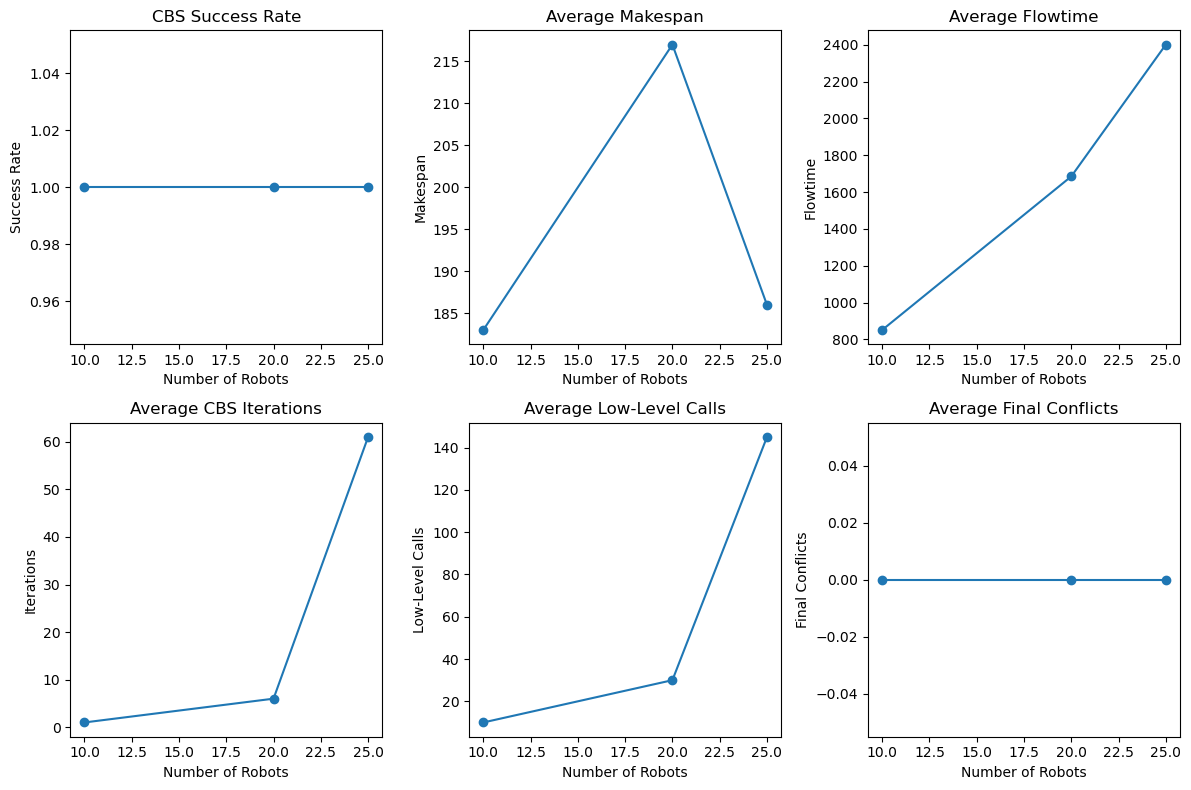

In [18]:
# Running CBS 10 times for 10, 20, 25 robots to get average performance metrics
grid = GridEnvironment('grid.txt')
robots_counts = [10, 20, 25]    
cbs_metrics = {n_robots: [] for n_robots in robots_counts}
print("\n=== Running CBS for Multiple Robot Counts (10 times each) ===")
for n_robots in robots_counts:
    print(f"\n=== Running CBS for {n_robots} Robots ===")
    robots = generate_random_robots(grid, n_robots=n_robots)  # Different seed for each run
    initial_state = {
        'grid': grid,
        'robots': robots,
        'positions': {r['id']: r['start_position'] for r in robots},
        'collsions': 0,
        'deadlock': False,
    }
    metrics = []
    for i in range(10):
        problem = AutomatedWarehouseRobotControllerProblem(initial_state)
        # print(f"\n--- CBS Run {i+1} ---")
        cbs = ConflictBasedSearch(problem, CooperativeAStar, conflict_detector=ConflictDetector(), objective="flowtime", max_iterations=10000, timeout=60)
        cbs_result = cbs.solve(time_limit=20)
        metrics.append({
            'paths': cbs_result['paths'],
            'success': cbs_result['success'],
            'makespan': cbs_result['makespan'],
            'flowtime': cbs_result['flowtime'],
            'cbs_iterations': cbs_result['cbs_iterations'],
            'low_level_calls': cbs_result['low_level_calls'],
            'final_conflicts': cbs_result['final_conflicts'],
        })

    # Calculate average metrics after each run
    avg_metrics = {
        'success_rate': sum(m['success'] for m in metrics) / len(metrics),
        'average_makespan': sum(m['makespan'] for m in metrics) / len(metrics),
        'average_flowtime': sum(m['flowtime'] for m in metrics) / len(metrics),
        'average_cbs_iterations': sum(m['cbs_iterations'] for m in metrics) / len(metrics),
        'average_low_level_calls':  sum(m['low_level_calls'] for m in metrics) / len(metrics),
        'average_final_conflicts': sum(m['final_conflicts'] for m in metrics) / len(metrics),
    }
    print(f"\n Average CBS Performance Metrics for {n_robots} Robots:")
    print(f"  Success Rate: {avg_metrics['success_rate']:.2f}")
    print(f"  Average Makespan: {avg_metrics['average_makespan']:.2f}")
    print(f"  Average Flowtime: {avg_metrics['average_flowtime']:.2f}")
    print(f"  Average CBS Iterations: {avg_metrics['average_cbs_iterations']:.2f}")
    print(f"  Average Low-Level Calls: {avg_metrics['average_low_level_calls']:.2f}")
    print(f"  Average Final Conflicts: {avg_metrics['average_final_conflicts']:.2f}")

    cbs_metrics[n_robots] = metrics  # Store metrics for this robot count
    
# Plot the statistics
import matplotlib.pyplot as plt
def plot_cbs_metrics(cbs_metrics):
    robot_counts = sorted(cbs_metrics.keys())
    success_rates = [sum(m['success'] for m in cbs_metrics[n]) / len(cbs_metrics[n]) for n in robot_counts]
    average_makespans = [sum(m['makespan'] for m in cbs_metrics[n]) / len(cbs_metrics[n]) for n in robot_counts]
    average_flowtimes = [sum(m['flowtime'] for m in cbs_metrics[n]) / len(cbs_metrics[n]) for n in robot_counts]
    average_iterations = [sum(m['cbs_iterations'] for m in cbs_metrics[n]) / len(cbs_metrics[n]) for n in robot_counts]
    average_low_level_calls = [sum(m['low_level_calls'] for m in cbs_metrics[n]) / len(cbs_metrics[n]) for n in robot_counts]
    average_final_conflicts = [sum(m['final_conflicts'] for m in cbs_metrics[n]) / len(cbs_metrics[n]) for n in robot_counts]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.plot(robot_counts, success_rates, marker='o')
    plt.title('CBS Success Rate')
    plt.xlabel('Number of Robots')
    plt.ylabel('Success Rate')

    plt.subplot(2, 3, 2)
    plt.plot(robot_counts, average_makespans, marker='o')
    plt.title('Average Makespan')
    plt.xlabel('Number of Robots')
    plt.ylabel('Makespan')

    plt.subplot(2, 3, 3)
    plt.plot(robot_counts, average_flowtimes, marker='o')
    plt.title('Average Flowtime')
    plt.xlabel('Number of Robots')
    plt.ylabel('Flowtime')

    plt.subplot(2, 3, 4)
    plt.plot(robot_counts, average_iterations, marker='o')
    plt.title('Average CBS Iterations')
    plt.xlabel('Number of Robots')
    plt.ylabel('Iterations')

    plt.subplot(2, 3, 5)
    plt.plot(robot_counts, average_low_level_calls, marker='o')
    plt.title('Average Low-Level Calls')
    plt.xlabel('Number of Robots')
    plt.ylabel('Low-Level Calls')

    plt.subplot(2, 3, 6)
    plt.plot(robot_counts, average_final_conflicts, marker='o')
    plt.title('Average Final Conflicts')
    plt.xlabel('Number of Robots')
    plt.ylabel('Final Conflicts')

    plt.tight_layout()
    plt.show()

plot_cbs_metrics(cbs_metrics)

# Hill Climbing Optimizier Test

In [19]:
# Generate non optimal valid solutions for 10, 20, 25, 30, 35, 40, 50 robots and optimize them with hill climbing
# We use A* to generate initial solutions, then apply the HillClimbingOptimizer to improve them, and compare metrics before and after optimization.
# A* gives optimal solutons, so we mess them, add waits, add redundant moves, and then optimize with hill climbing to see how much improvement we can get.
grid = GridEnvironment('grid.txt')
robots_counts = [10, 20, 25, 30, 35, 40, 50]
hill_climbing_metrics = {n_robots: [] for n_robots in robots_counts}
print("\n=== Running Hill Climbing Optimization for Multiple Robot Counts (10 times each) ===")
for n_robots in robots_counts:
    print(f"\n=== Running Hill Climbing Optimization for {n_robots} Robots ===")
    robots = generate_random_robots(grid, n_robots=n_robots, seed=100)  # Different seed for each run
    initial_state = {
        'grid': grid,
        'robots': robots,
        'positions': {r['id']: r['start_position'] for r in robots},
        'collsions': 0,
        'deadlock': False,
    }
    metrics = []
    for i in range(10):
        problem = AutomatedWarehouseRobotControllerProblem(initial_state)
        coop_astar = CooperativeAStar(problem)
        initial_paths = coop_astar.solve()["paths"]  # Get optimal paths from A*
        

        # Mess up the optimal paths to create non-optimal solutions
        non_optimal_paths = copy.deepcopy(initial_paths)
        for rid, path in non_optimal_paths.items():
            if path is None or len(path) < 2:
                continue
            # Add redundant moves (back and forth)
            if len(path) > 2:
                non_optimal_paths[rid] = path[:1] + [path[1], path[0]] + path[1:]

            # Add waits at the start
            non_optimal_paths[rid] = [path[0]] * 3 + non_optimal_paths[rid]

        optimizer = HillClimbingOptimizer(conflict_detector=ConflictDetector())
        optimized_paths = optimizer.optimize(non_optimal_paths, grid, max_iterations=500, timeout=15)

        # Evaluate metrics before and after optimization
        def evaluate(paths):
            conflicts = optimizer.conflict_detector.detect_conflicts(paths)
            conflict_count = len(conflicts)
            makespan = max(len(p) for p in paths.values() if p is not None) - 1 if paths else float("inf")
            flowtime = sum(len(p) - 1 for p in paths.values() if p is not None) if paths else float("inf")
            return conflict_count, makespan, flowtime

        initial_conflicts, initial_makespan, initial_flowtime = evaluate(non_optimal_paths)
        optimized_conflicts, optimized_makespan, optimized_flowtime = evaluate(optimized_paths)

        metrics.append({
            'initial_conflicts': initial_conflicts,
            'initial_makespan': initial_makespan,
            'initial_flowtime': initial_flowtime,
            'optimized_conflicts': optimized_conflicts,
            'optimized_makespan': optimized_makespan,
            'optimized_flowtime': optimized_flowtime,
            'iterations': optimizer.iteration_count,
        })

    # Calculate average metrics after each run
    avg_metrics = {
        'average_initial_conflicts': sum(m['initial_conflicts'] for m in metrics) / len(metrics),
        'average_initial_makespan': sum(m['initial_makespan'] for m in metrics) / len(metrics),
        'average_initial_flowtime': sum(m['initial_flowtime'] for m in metrics) / len(metrics),
        'average_optimized_conflicts': sum(m['optimized_conflicts'] for m in metrics) / len(metrics),
        'average_optimized_makespan': sum(m['optimized_makespan'] for m in metrics) / len(metrics),
        'average_optimized_flowtime': sum(m['optimized_flowtime'] for m in metrics) / len(metrics),
        'average_iterations': sum(m['iterations'] for m in metrics) / len(metrics),
    }
    print(f"\n Average Hill Climbing Optimization Metrics for {n_robots} Robots:")
    print(f"  Average Initial Conflicts: {avg_metrics['average_initial_conflicts']:.2f}")
    print(f"  Average Initial Makespan: {avg_metrics['average_initial_makespan']:.2f}")
    print(f"  Average Initial Flowtime: {avg_metrics['average_initial_flowtime']:.2f}")
    print(f"  Average Optimized Conflicts: {avg_metrics['average_optimized_conflicts']:.2f}")
    print(f"  Average Optimized Makespan: {avg_metrics['average_optimized_makespan']:.2f}")
    print(f"  Average Optimized Flowtime: {avg_metrics['average_optimized_flowtime']:.2f}")
    print(f"  Average Iterations: {avg_metrics['average_iterations']:.2f}")

    hill_climbing_metrics[n_robots] = metrics  # Store metrics for this robot count




=== Running Hill Climbing Optimization for Multiple Robot Counts (10 times each) ===

=== Running Hill Climbing Optimization for 10 Robots ===

 Average Hill Climbing Optimization Metrics for 10 Robots:
  Average Initial Conflicts: 0.00
  Average Initial Makespan: 155.00
  Average Initial Flowtime: 1086.00
  Average Optimized Conflicts: 0.00
  Average Optimized Makespan: 150.00
  Average Optimized Flowtime: 1041.00
  Average Iterations: 2.00

=== Running Hill Climbing Optimization for 20 Robots ===

 Average Hill Climbing Optimization Metrics for 20 Robots:
  Average Initial Conflicts: 0.00
  Average Initial Makespan: 189.00
  Average Initial Flowtime: 1918.00
  Average Optimized Conflicts: 0.00
  Average Optimized Makespan: 184.00
  Average Optimized Flowtime: 1823.00
  Average Iterations: 2.00

=== Running Hill Climbing Optimization for 25 Robots ===

 Average Hill Climbing Optimization Metrics for 25 Robots:
  Average Initial Conflicts: 0.00
  Average Initial Makespan: 193.00
  Ave

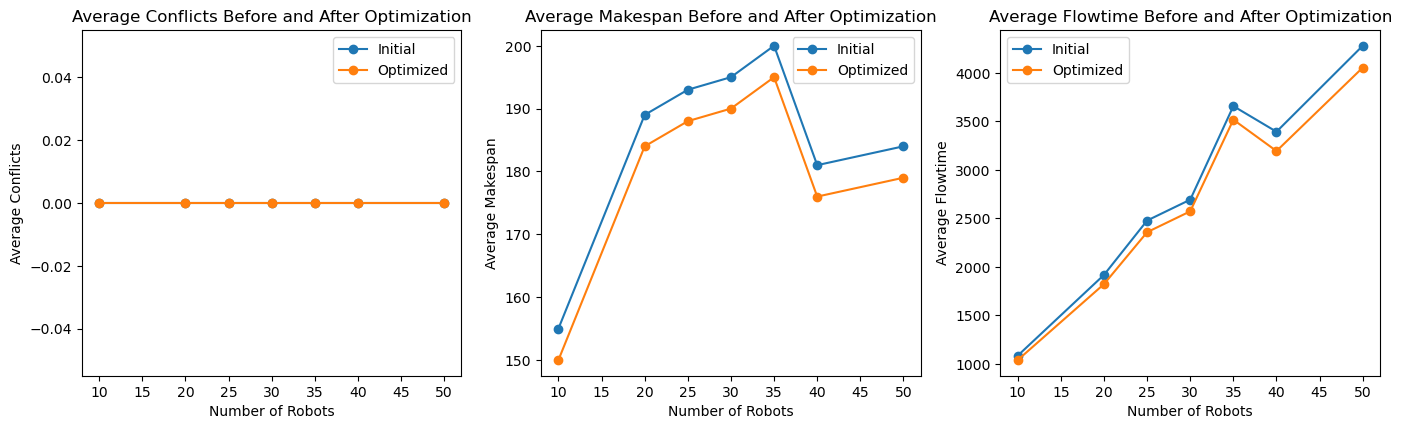

In [21]:
# Plot the optimization results
def plot_hill_climbing_metrics(hill_climbing_metrics):  
    robot_counts = sorted(hill_climbing_metrics.keys())
    avg_initial_conflicts = [sum(m['initial_conflicts'] for m in hill_climbing_metrics[n]) / len(hill_climbing_metrics[n]) for n in robot_counts]
    avg_initial_makespan = [sum(m['initial_makespan'] for m in hill_climbing_metrics[n]) / len(hill_climbing_metrics[n]) for n in robot_counts]
    avg_initial_flowtime = [sum(m['initial_flowtime'] for m in hill_climbing_metrics[n]) / len(hill_climbing_metrics[n]) for n in robot_counts]
    avg_optimized_conflicts = [sum(m['optimized_conflicts'] for m in hill_climbing_metrics[n]) / len(hill_climbing_metrics[n]) for n in robot_counts]
    avg_optimized_makespan = [sum(m['optimized_makespan'] for m in hill_climbing_metrics[n]) / len(hill_climbing_metrics[n]) for n in robot_counts]
    avg_optimized_flowtime = [sum(m['optimized_flowtime'] for m in hill_climbing_metrics[n]) / len(hill_climbing_metrics[n]) for n in robot_counts]


    plt.figure(figsize=(14, 8))

    plt.subplot(2, 3, 1)
    plt.plot(robot_counts, avg_initial_conflicts, marker='o', label='Initial')
    plt.plot(robot_counts, avg_optimized_conflicts, marker='o', label='Optimized')
    plt.title('Average Conflicts Before and After Optimization')
    plt.xlabel('Number of Robots')
    plt.ylabel('Average Conflicts')
    plt.legend()

    plt.subplot(2, 3, 2)
    plt.plot(robot_counts, avg_initial_makespan, marker='o', label='Initial')
    plt.plot(robot_counts, avg_optimized_makespan, marker='o', label='Optimized')
    plt.title('Average Makespan Before and After Optimization')
    plt.xlabel('Number of Robots')
    plt.ylabel('Average Makespan')
    plt.legend()

    plt.subplot(2, 3, 3)
    plt.plot(robot_counts, avg_initial_flowtime, marker='o', label='Initial')
    plt.plot(robot_counts, avg_optimized_flowtime, marker='o', label='Optimized')
    plt.title('Average Flowtime Before and After Optimization')
    plt.xlabel('Number of Robots')
    plt.ylabel('Average Flowtime')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_hill_climbing_metrics(hill_climbing_metrics)